# Notebook 1 : Geyser Old Faithful 🌋

In [61]:
# Décommenter la ligne suivante pour installer les dépendances
# %pip install jupyter_bokeh nbconvert panel watchfiles

In [62]:
import matplotlib.pyplot as plt
import pandas as pd
import panel as pn

pn.extension()

Nous considérons des données relatives aux éruptions du geyser [Old Faithful](https://fr.wikipedia.org/wiki/Old_Faithful) situé dans le parc national de Yellowstone aux États-Unis.

## Préliminaires

1. Écrire une fonction `get_data` sans argument qui retourne les données contenues dans le fichier `data/faithful.csv` sous la forme d'un DataFrame Pandas. Cette fontion a vocation à être appelée plusieurs fois avec le même résultat attendu, elle pourra donc être décorée avec `pn.cache`.

In [63]:
def get_data() :
    return pd.read_csv("/home/onyxia/work/formation_cepe/Bloc4/viz/data/faithful.csv")

In [64]:
df=get_data()
df

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85
...,...,...
267,4.117,81
268,2.150,46
269,4.417,90
270,1.817,46


2. Utiliser la fonction `hist` de Matplotlib (voir [la documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html)) pour visualiser la fréquence des éruptions en fonction du temps d'attente `waiting` sous la forme d'un histogramme. Comprendre le rôle des paramètres `bins`, `density`, `histtype` et `color`.

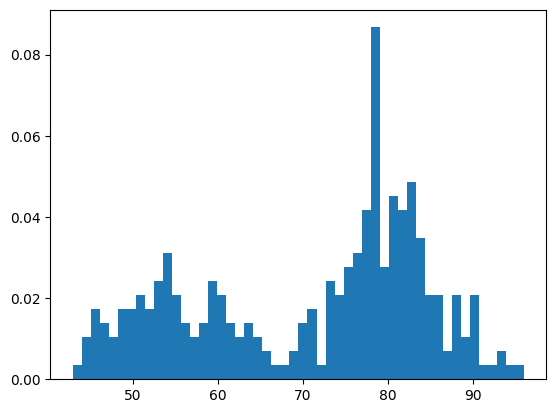

In [65]:
plt.hist(df['waiting'], bins=50, density=True)
plt.show()

3. Écrire une fonction `get_faithful_hist` avec les arguments `bins` (`30` par défaut), `density` (`True` par défaut), `histtype` (`"bar"` par défaut) et `color` (`"orange"` par défaut) qui retourne l'objet graphique Matplotlib de l'histogramme précédent. Penser à fermer la figure avec `plt.close` avant de la retourner pour éviter les fuites de mémoire.

In [ ]:
def get_faithful_hist(bins=30, density=True, histtype='bar', color='orange'):
    fig, ax = plt.subplots()
    ax.hist(df.waiting, bins=bins, density=density, histtype=histtype, color=color)
    ax.set_xlabel("Temps avant la prochaine éruption (min)")
    ax.set_ylabel("Fréquence")
    plt.close(fig)
    return fig

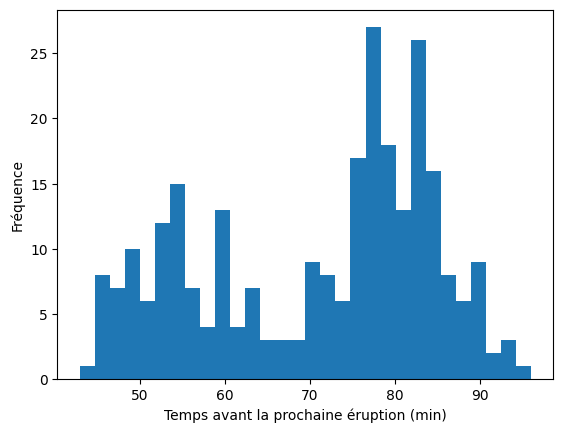

In [67]:
get_faithful_hist()

## Panel dans un notebook

Une des forces de Panel est de permettre l'expérimentation dans un notebook avant de mettre en place l'application web, le tout dans un seul et même fichier.

4. Nous utiliserons une glissière de type `IntSlider` (voir [la documentation](https://panel.holoviz.org/reference/widgets/IntSlider.html)) pour sélectionner le nombre de blocs de l'histogramme. Pour découvrir ce widget, créer une glissière allant de `1` à `50` avec une valeur par défaut de `30`. Afficher l'objet dans le notebook avec un nom (`name`) associé. Quel est le type de l'attribut `value` de cet objet ?

In [ ]:
widget_bins = pn.widgets.IntSlider(name="Nombre de bins", start=1, end=50, value=30)
widget_bins

BokehModel(combine_events=True, render_bundle={'docs_json': {'08cfbbac-a01c-4e2d-b215-d557e2545213': {'version…

5. Utiliser la mise en page (*layout*) `Column` (voir [la documentation](https://panel.holoviz.org/reference/layouts/Column.html)) pour empiler :

    - une glissière `bins` avec les mêmes paramètres que dans la question précédente,
    - un *pane* `Matplotlib` (voir [la documentation](https://panel.holoviz.org/reference/panes/Matplotlib.html)) qui affichera le résultat de la fonction `get_faithful_hist`.

    Ces deux éléments doivent être liés à l'aide de `pn.bind` en utilisant la valeur de la glissière pour le paramètre `bins` de la fonction `get_faithful_hist`. Faire varier la valeur du widget pour visualiser l'interaction.

In [ ]:
param_bins = pn.bind(get_faithful_hist, bins=widget_bins)

pn.Column(widget_bins, pn.pane.Matplotlib(param_bins)).servable()

BokehModel(combine_events=True, render_bundle={'docs_json': {'c59b6717-34d2-47b0-81c4-2bdb54fdac28': {'version…

## Application web

Nous pouvons maintenant mettre en place une application web qui pourra être démarrée avec la commande suivante (l'option `--allow-websocket-origin` n'est nécessaire que dans Onyxia) :
```{bash}
panel serve --autoreload --show --allow-websocket-origin=$(echo $VSCODE_PROXY_URI | cut -d '/' -f 3) notebooks/01_old_faithful.ipynb
```

Les questions suivantes ont pour objet d'enrichir l'application au fur et à mesure. Il ne faut donc pas recréer une nouvelle application pour chaque question mais faire évoluer le code étape par étape. Il peut être utile d'ajouter de nouvelles cellules de code si besoin.

6. Mettre en forme une application à l'aide du modèle `FastListTemplate` (voir [la documentation](https://panel.holoviz.org/reference/templates/FastListTemplate.html)) avec le widget `bins` dans la barre latérale et le *pane* du graphique obtenu avec `get_faithful_hist` dans la zone principale. Penser à utiliser la méthode `servable` pour afficher le résultat dans l'application.

7. Ajouter une case à cocher `density` de type `Checkbox` (voir [la documentation](https://panel.holoviz.org/reference/widgets/Checkbox.html)) pour choisir si la visualisation représente les effectifs ou les fréquences. Quel est le type de l'attribut `value` de cet objet ? Utiliser la valeur de ce widget pour le paramètre `density` lors du lien avec la fonction `get_faithful_hist`.

8. Ajouter un menu déroulant `histtype` de type `Select` (voir [la documentation](https://panel.holoviz.org/reference/widgets/Select.html)) pour choisir si l'histogramme est affiché plein ou seulement son contour. Quel est le type de l'attribut `value` de cet objet ? Utiliser la valeur de ce widget pour le paramètre `histtype` lors du lien avec la fonction `get_faithful_hist`.

9. Ajouter un sélecteur de couleur `color` de type `ColorPicker` (voir [la documentation](https://panel.holoviz.org/reference/widgets/ColorPicker.html)) avec le orange par défaut pour sélectionner la couleur de l'histogramme. Quel est le type de l'attribut `value` de cet objet ? Utiliser la valeur de ce widget pour le paramètre `color` lors du lien avec la fonction `get_faithful_hist`.